In [3]:
import pandas as pd
import itertools
import networkx as nx
import matplotlib.pyplot as plt
from graph_tool.all import Graph, graph_draw, sfdp_layout
import numpy as np
import os
import graph_tool.all as gt
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

This ipynb takes the endered and cleaned data to generate yearly networks and make a video out of those.

### import data and preprocess

In [4]:
authors_df = pd.read_csv('authors_cleaned.csv')

In [5]:
authors_df.head()

,PMID,DescriptorName_UI,LastName,ForeName,AID,ORCID,Journal_JournalIssue_PubDate_MedlineDate,Journal_JournalIssue_PubDate_Year,Gender,Publication_Year,Century_Decade,Mention,author_name
0,11584014,D011471,Leskow,Federico,4880994,NaN,NaN,2002,male,2002,2000-2010,prostate,Federico Leskow
1,11584014,D011471,Fujii,Teruhiko,6757189,NaN,NaN,2002,male,2002,2000-2010,prostate,Teruhiko Fujii
2,11584014,D011471,Wang,Qiming,5191708,NaN,NaN,2002,male,2002,2000-2010,prostate,Qiming Wang
3,11584014,D011471,Blumberg,Peter,3687806,NaN,NaN,2002,male,2002,2000-2010,prostate,Peter Blumberg
4,11584014,D011471,Ohba,Motoi,8648208,NaN,NaN,2002,male,2002,2000-2010,prostate,Motoi Ohba


In [6]:
authors_df['Publication_Year'].nunique()

19

# plot authors over time

### prepare data

In [7]:
authors_df.isna().sum()

PMID                                             0
DescriptorName_UI                                0
LastName                                         0
ForeName                                         0
AID                                              0
ORCID                                       421255
Journal_JournalIssue_PubDate_MedlineDate    398469
Journal_JournalIssue_PubDate_Year                0
Gender                                           0
Publication_Year                                 0
Century_Decade                                   0
Mention                                          0
author_name                                      0
dtype: int64

In [8]:
#convert to int
authors_df['Publication_Year'] = authors_df['Publication_Year'].astype(int)

authors_df['Publication_Year'].unique()

array([2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012,
       2013, 2014, 2015, 2016, 2017, 2019, 2018, 2020])

In [9]:
authors_per_year = authors_df.groupby('Publication_Year')['AID'].nunique()  #count unique authors (AID)
print(authors_per_year)

Publication_Year
2002    21306
2003    16200
2004    15508
2005    16123
2006    15011
2007    15694
2008    16142
2009    18301
2010    21627
2011    22501
2012    26038
2013    26355
2014    27255
2015    28390
2016    28439
2017    28162
2018    29233
2019    33769
2020    15201
Name: AID, dtype: int64


In [10]:
breast = authors_df[authors_df['Mention'] == 'breast']
prostate = authors_df[(authors_df['Mention'] == 'prostate')]

## cummulative authors per year

In [11]:
def plot_cumulative_authors_per_year(authors_df, output_prefix="authors_per_year"):
    authors_per_year = authors_df.groupby('Publication_Year')['AID'].nunique()  #count unique authors (AID)
    
    cumulative_authors = authors_per_year.cumsum() #cummulative sum

    plt.figure(figsize=(10, 6))
    cumulative_authors.plot(kind='line', marker='o', color='b')
    
    plt.title('Cumulative Number of Authors Per Year')
    plt.xlabel('Year')
    plt.ylabel('Cumulative Number of Authors')
    plt.xticks(np.arange(2002, 2022, 2))
    plt.grid(True)
    
    #save plot
    output_file = f"{output_prefix}_cumulative_authors_per_year.png"
    plt.savefig(output_file)
    plt.show()
    
    return authors_per_year, cumulative_authors

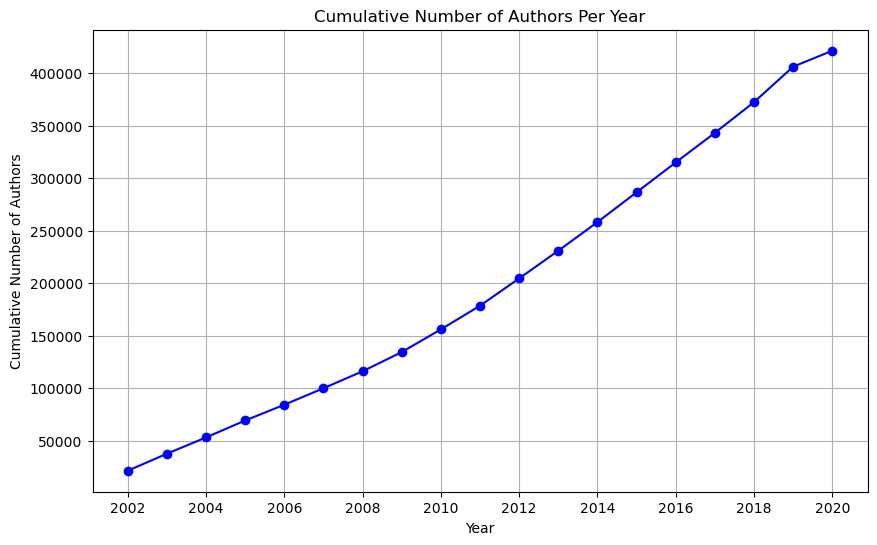

(Publication_Year
 2002    21306
 2003    16200
 2004    15508
 2005    16123
 2006    15011
 2007    15694
 2008    16142
 2009    18301
 2010    21627
 2011    22501
 2012    26038
 2013    26355
 2014    27255
 2015    28390
 2016    28439
 2017    28162
 2018    29233
 2019    33769
 2020    15201
 Name: AID, dtype: int64,
 Publication_Year
 2002     21306
 2003     37506
 2004     53014
 2005     69137
 2006     84148
 2007     99842
 2008    115984
 2009    134285
 2010    155912
 2011    178413
 2012    204451
 2013    230806
 2014    258061
 2015    286451
 2016    314890
 2017    343052
 2018    372285
 2019    406054
 2020    421255
 Name: AID, dtype: int64)

In [12]:
plot_cumulative_authors_per_year(authors_df, output_prefix="authors_per_year")

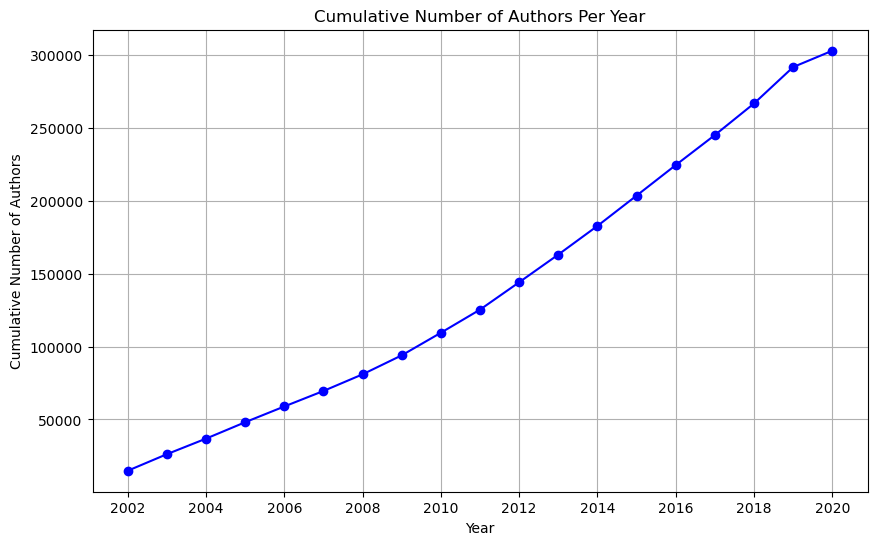

(Publication_Year
 2002    14853
 2003    11350
 2004    10667
 2005    11250
 2006    10808
 2007    10632
 2008    11419
 2009    13020
 2010    15488
 2011    15861
 2012    18768
 2013    18992
 2014    19652
 2015    20787
 2016    20947
 2017    20597
 2018    21657
 2019    24973
 2020    11208
 Name: AID, dtype: int64,
 Publication_Year
 2002     14853
 2003     26203
 2004     36870
 2005     48120
 2006     58928
 2007     69560
 2008     80979
 2009     93999
 2010    109487
 2011    125348
 2012    144116
 2013    163108
 2014    182760
 2015    203547
 2016    224494
 2017    245091
 2018    266748
 2019    291721
 2020    302929
 Name: AID, dtype: int64)

In [13]:
plot_cumulative_authors_per_year(breast, output_prefix="breast_cancer_authors_per_year")

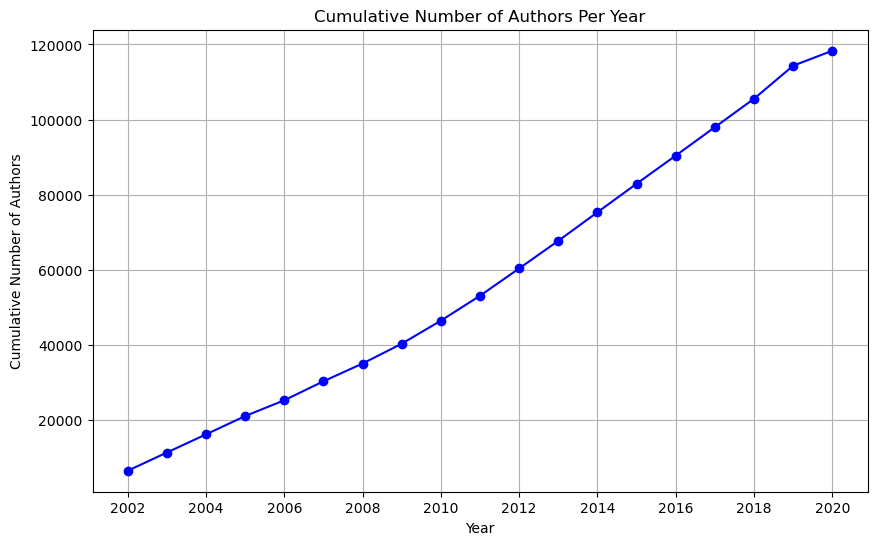

(Publication_Year
 2002    6453
 2003    4850
 2004    4841
 2005    4873
 2006    4203
 2007    5062
 2008    4723
 2009    5281
 2010    6139
 2011    6640
 2012    7270
 2013    7363
 2014    7603
 2015    7603
 2016    7492
 2017    7565
 2018    7576
 2019    8796
 2020    3993
 Name: AID, dtype: int64,
 Publication_Year
 2002      6453
 2003     11303
 2004     16144
 2005     21017
 2006     25220
 2007     30282
 2008     35005
 2009     40286
 2010     46425
 2011     53065
 2012     60335
 2013     67698
 2014     75301
 2015     82904
 2016     90396
 2017     97961
 2018    105537
 2019    114333
 2020    118326
 Name: AID, dtype: int64)

In [14]:
plot_cumulative_authors_per_year(prostate, output_prefix="prostate_cancer_authors_per_year")

## histogram of authors per year

In [15]:
def plot_authors_histogram(authors_df, output_prefix="authors_histogram", disease=None):
    authors_per_year = authors_df.groupby('Publication_Year')['AID'].nunique()

    plt.figure(figsize=(10, 6))
    plt.bar(authors_per_year.index, authors_per_year.values, color='skyblue', edgecolor='black')

    plt.title('Number of Unique Authors Per Year', disease)
    plt.xlabel('Publication Year')
    plt.ylabel('Number of Unique Authors')
    plt.xticks(np.arange(2002, 2022, 2))
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    output_file = f"{output_prefix}.png"
    plt.savefig(output_file)
    plt.show()

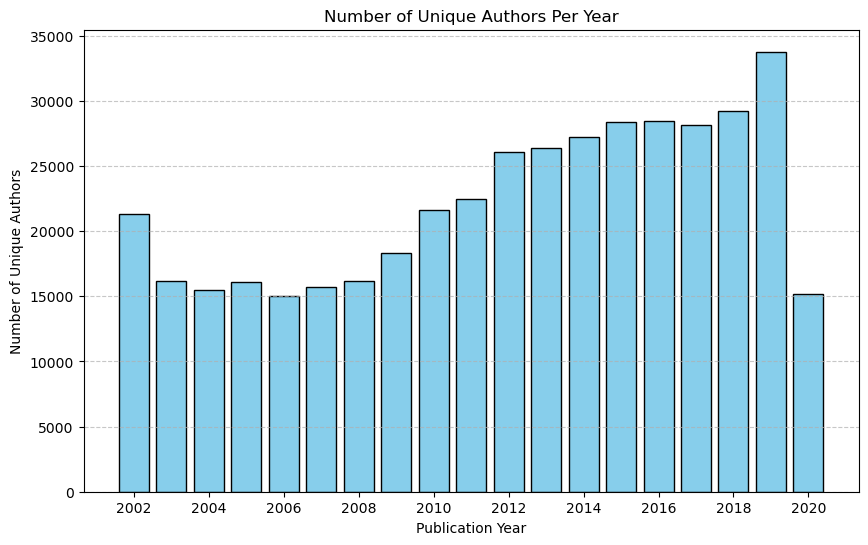

In [16]:
plot_authors_histogram(authors_df, output_prefix="authors_per_year")

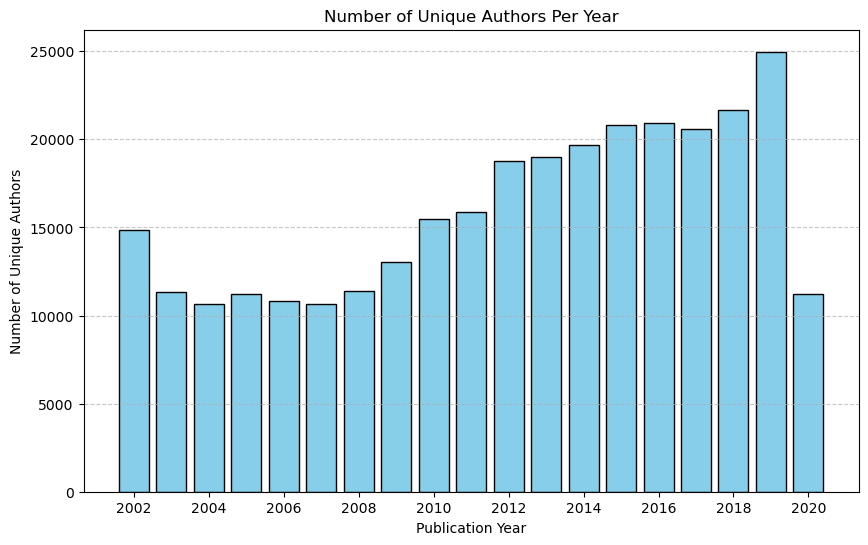

In [17]:
plot_authors_histogram(breast, output_prefix="breast_cancer_authors_per_year")

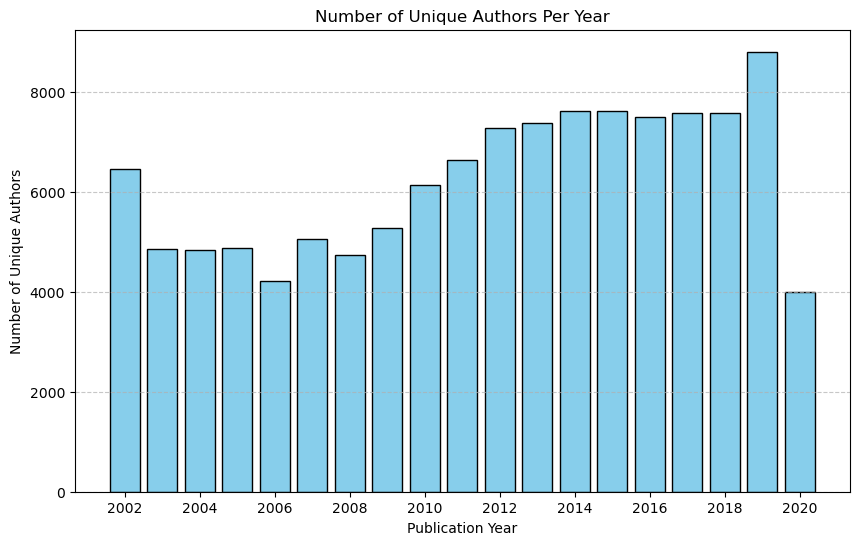

In [18]:
plot_authors_histogram(prostate, output_prefix="prostate_cancer_authors_per_year")

# plot yearly networks

In [49]:
def process_coauthorship_graph(authors_df, disease, year, output_prefix="network"):

    #filter out authors with less than 5 publications overall (all 20 years)
    total_author_counts = authors_df.groupby("AID").size()
    authors_with_at_least_5 = total_author_counts[total_author_counts >= 5].index
    prolific_authors_df = authors_df[authors_df["AID"].isin(authors_with_at_least_5)].copy()

    year_df = prolific_authors_df[prolific_authors_df["Publication_Year"] == year].copy()

    year_df = authors_df[authors_df["Publication_Year"] == year]

    #filter for disease
    disease_authors = year_df[year_df["Mention"] == disease].copy()

    if disease_authors.empty:
        print(f"No data for {disease} in the dataset. Skipping...")
        return 

    #group by publication
    grouped_authors = disease_authors.groupby("PMID")

    #edges
    coauthorship_edges = []
    for _, group in grouped_authors:
        authors = group[["LastName", "ForeName"]].apply(tuple, axis=1).tolist()
        coauthorship_edges.extend(itertools.combinations(authors, 2))  #create co-author pairs

    #generate network
    coauthorship_graph = nx.Graph()

    #add authors
    for _, group in grouped_authors:
        for _, row in group.iterrows():
            coauthorship_graph.add_node((row["LastName"], row["ForeName"]), gender=row["Gender"])

    #add edges
    coauthorship_graph.add_edges_from(coauthorship_edges)

    #security check
    if len(coauthorship_graph.nodes()) == 0 or len(coauthorship_graph.edges()) == 0:
        print(f"No co-authorship data found for {disease}. Skipping graph creation.")
        return
    
    #convert to graph-tool for visualization
    g = Graph(directed=False)
    node_mapping = {}

    for node in coauthorship_graph.nodes():
        node_mapping[node] = g.add_vertex() 

    for u, v in coauthorship_graph.edges():
        g.add_edge(node_mapping[u], node_mapping[v])

    #assign color
    pcolor = g.new_vertex_property("string")
    gender_colors = {
        "male": "darkorchid",
        "female": "darkorange",
        "unknown": "darkgray",
    }

    for node, vertex in node_mapping.items():
        gender = coauthorship_graph.nodes[node].get("gender", "unknown")
        pcolor[vertex] = gender_colors.get(gender, "gray")

    pos = sfdp_layout(g, cooling_step=0.95, epsilon=1e-3, gamma=5)
    output_file = f"{output_prefix}_{disease}_{year}_graph.png"

    graph_draw(
        g,
        pos=pos,
        vertex_fill_color=pcolor,
        edge_color=(1, 1, 1, 0),
        output_size=(7000, 7000),
        output=output_file,
    )

    #save network statistics
    os.makedirs("Networks_Years", exist_ok=True)
    network_stats_file = f"{output_prefix}_{disease}_{year}_stats.txt"
    with open(network_stats_file, "w") as stats_file:
        stats_file.write(f"Number of nodes: {coauthorship_graph.number_of_nodes()}\n")
        stats_file.write(f"Number of edges: {coauthorship_graph.number_of_edges()}\n")
        stats_file.write(f"Density: {nx.density(coauthorship_graph):.4f}\n")
        degrees = dict(coauthorship_graph.degree())
        stats_file.write(f"Max degree: {max(degrees.values())}\n")
        stats_file.write(f"Avg degree: {sum(degrees.values()) / len(degrees):.2f}\n")

In [50]:
years = authors_df['Publication_Year'].unique()

In [51]:
years

array([2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012,
       2013, 2014, 2015, 2016, 2017, 2019, 2018, 2020])

## prostate

In [52]:
for year in years:
    process_coauthorship_graph(authors_df, disease = "prostate", year = year, output_prefix=f"prostate_network_{year}")  

## breast

In [53]:
for year in years:
    process_coauthorship_graph(authors_df, disease = "breast", year = year, output_prefix=f"breast_network_{year}")  